# **Lab 3. Шаврин Алексей Павлович гр. 1306**

# Установка зависимостей

In [6]:
!pip install opencv-python-headless matplotlib

# Импорт

In [7]:
import zipfile
import glob
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random

# Загрузка данных

In [8]:
with zipfile.ZipFile('Фото.zip', 'r') as zip_ref:
    zip_ref.extractall('photos')

In [9]:
image_paths = glob.glob('photos/*.JPG')[:2]
image_paths.sort()
print(image_paths)

['photos/DSC02692.JPG', 'photos/DSC02694.JPG']


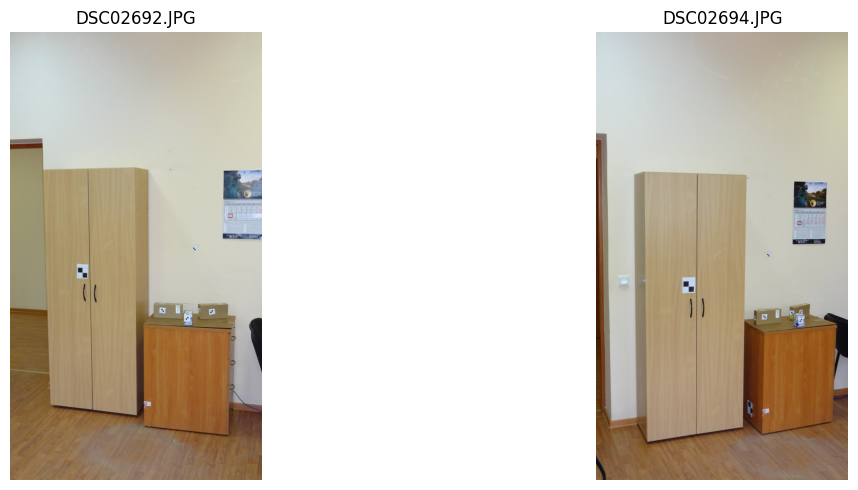

Загружено 2 изображений


In [10]:
images = []   # изображения
names = []    # имена файлов

plt.figure(figsize=(15, 5))
for i, path in enumerate(image_paths):
    img = cv2.imread(path)
    if img is None:
        print(f"Не удалось загрузить {path}")
        continue
    img_name = path.split('/')[-1]
    names.append(img_name)
    images.append(img)

    # визуализация загруженных фото
    plt.subplot(1, 2, i+1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(img_name)
    plt.axis('off')
plt.tight_layout()
plt.show()

print(f"Загружено {len(images)} изображений")

# Поиск и сопоставление SIFT-признаков (ключевые точки и их дескрипторы)

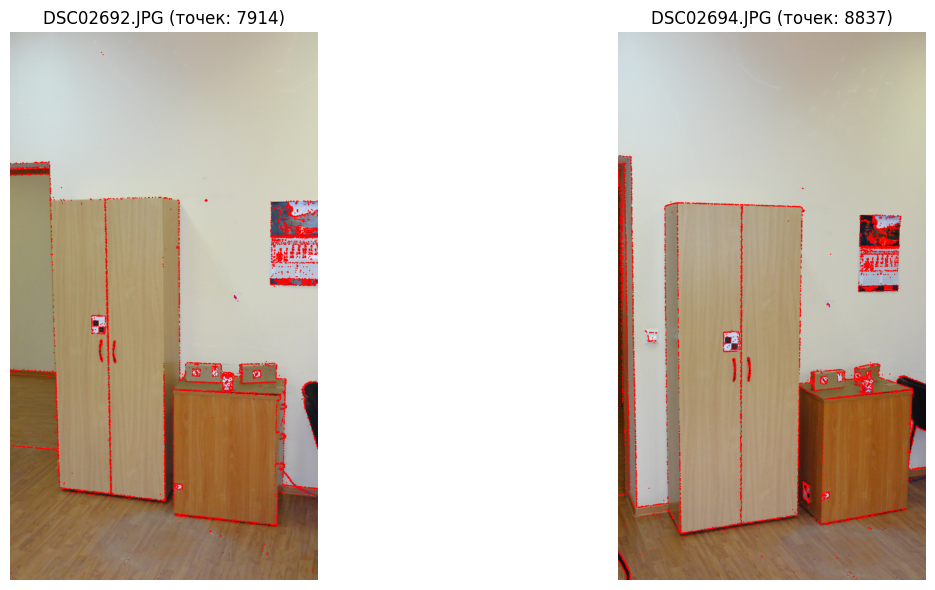

In [11]:
sift = cv2.SIFT_create()
kps = []          # ключевые точки
descs = []        # дескрипторы
gray_images = []

plt.figure(figsize=(15, 6))
for i, (img, name) in enumerate(zip(images, names)):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray_images.append(gray)
    kp, d = sift.detectAndCompute(gray, None)
    kps.append(kp)
    descs.append(d)

    # визуализация ключевых точек
    img_with_kp = img.copy()
    for point in kp:
        x, y = int(point.pt[0]), int(point.pt[1])
        cv2.circle(img_with_kp, (x, y), 5, (0, 0, 255), -1)

    plt.subplot(1, 2, i+1)
    plt.imshow(cv2.cvtColor(img_with_kp, cv2.COLOR_BGR2RGB))
    plt.title(f"{name} (точек: {len(kp)})")
    plt.axis('off')

plt.tight_layout()
plt.show()

# FLANN matcher

In [12]:
FLANN_INDEX_KDTREE = 1  # использует k‑dimensional tree для SIFT признаков
index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
search_params = dict(checks=50)
flann = cv2.FlannBasedMatcher(index_params, search_params)
matches = flann.knnMatch(descs[0], descs[1], k=2)

# Применяем Lowe's ratio test

In [13]:
def draw_matches_thick(img1, kp1, img2, kp2, matches, thickness=4):
    h1, w1 = img1.shape[:2]
    h2, w2 = img2.shape[:2]
    result = np.hstack((img1, img2))
    for m in matches:
        color = (random.randint(0, 255), random.randint(0, 255), random.randint(0, 255))
        x1, y1 = int(kp1[m.queryIdx].pt[0]), int(kp1[m.queryIdx].pt[1])
        x2, y2 = int(kp2[m.trainIdx].pt[0]) + w1, int(kp2[m.trainIdx].pt[1])
        cv2.line(result, (x1, y1), (x2, y2), color, thickness)
    return result

In [14]:
good = [m for m, n in matches if m.distance < 0.7 * n.distance]

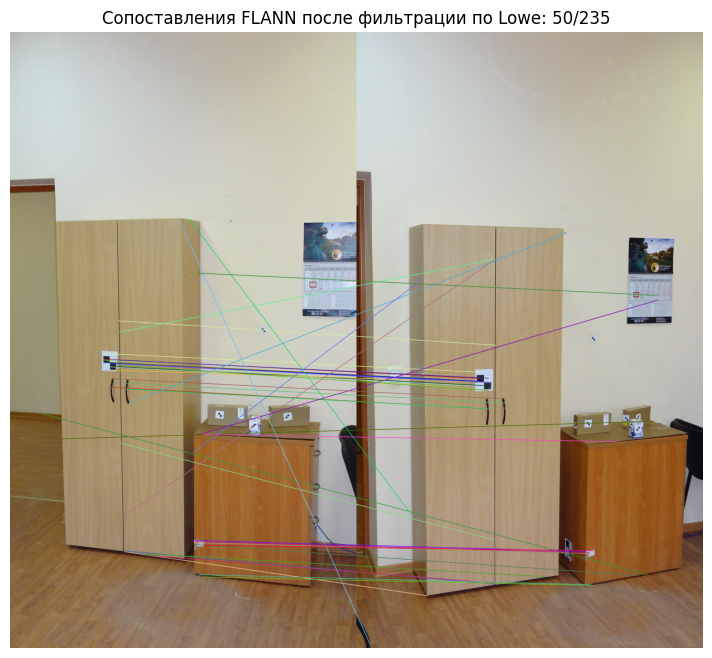

In [15]:
count_shown_good = min(50, len(good))

img_matches = draw_matches_thick(
    images[0], kps[0], images[1], kps[1],
    good[:count_shown_good]
)

plt.figure(figsize=(16, 8))
plt.imshow(cv2.cvtColor(img_matches, cv2.COLOR_BGR2RGB))
plt.title(f"Сопоставления FLANN после фильтрации по Lowe: {count_shown_good}/{len(good)}")
plt.axis('off')
plt.show()

# Вычисление координат соответствий

In [16]:
pts = [
    np.float32([kps[0][m.queryIdx].pt for m in good]),
    np.float32([kps[1][m.trainIdx].pt for m in good])
]

# Вычисляем фундаментальную матрицу и inliers

In [17]:
F, mask = cv2.findFundamentalMat(
    pts[0],
    pts[1],
    method=cv2.FM_RANSAC,
    ransacReprojThreshold=1.0,
    confidence=0.99
)

mask = mask.ravel().astype(bool)
inlier_pts = [p[mask] for p in pts]
inlier_matches = [good[i] for i in range(len(good)) if mask[i]]

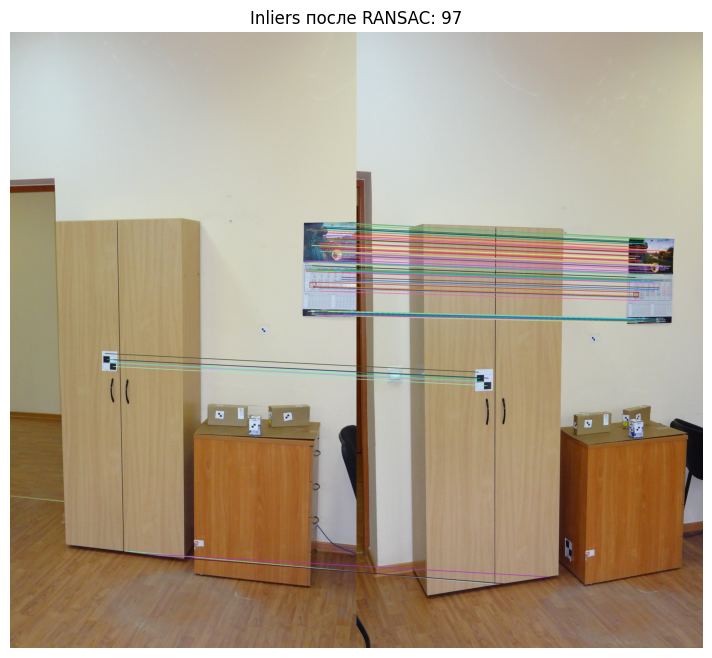

In [18]:
img_inliers = draw_matches_thick(images[0], kps[0], images[1], kps[1], inlier_matches)

plt.figure(figsize=(16, 8))
plt.imshow(cv2.cvtColor(img_inliers, cv2.COLOR_BGR2RGB))
plt.title(f"Inliers после RANSAC: {len(inlier_matches)}")
plt.axis('off')
plt.show()

# Ректификация

In [19]:
def show_rectified(rect_images, titles=None, step=100, figsize=(15, 6)):
    if titles is None:
        titles = ["Ректифицированное левое", "Ректифицированное правое"]

    images_with_lines = []
    for img in rect_images:
        color_img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
        for i in range(0, img.shape[0], step):
            cv2.line(color_img, (0, i), (img.shape[1], i), (255, 255, 0), 5)
        images_with_lines.append(cv2.cvtColor(color_img, cv2.COLOR_BGR2RGB))

    plt.figure(figsize=figsize)
    for i in range(2):
        plt.subplot(1, 2, i+1)
        plt.imshow(images_with_lines[i])
        plt.title(titles[i])
        plt.axis('off')

    plt.tight_layout()
    plt.show()

In [20]:
pts_in = [p.reshape(-1, 2) for p in inlier_pts]
h, w = gray_images[0].shape

ok, H1, H2 = cv2.stereoRectifyUncalibrated(
    pts_in[0], pts_in[1], F, imgSize=(w, h)
)
H = [H1, H2]

if not ok:
    raise RuntimeError("Ректификация не выполнена")

# Применение гомографий

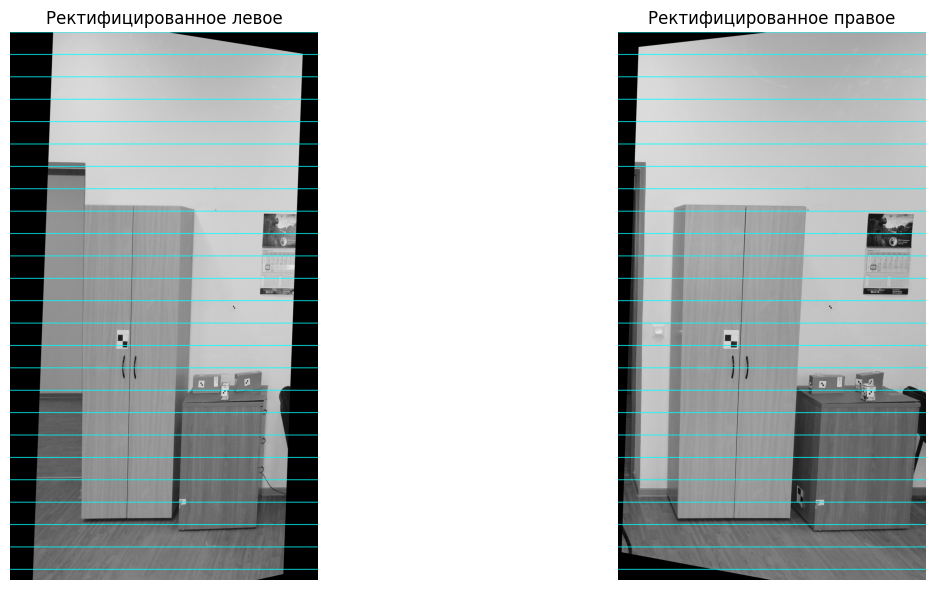

In [26]:
rect = [cv2.warpPerspective(gray_images[i], H[i], (w, h)) for i in range(2)]
show_rectified(rect)

In [22]:
masks = [(rect_i > 0).astype(np.uint8) * 255 for rect_i in rect]
common = cv2.bitwise_and(masks[0], masks[1])
coords = cv2.findNonZero(common)

if coords is None:
    raise RuntimeError("Нет общей области")

x, y, wc, hc = cv2.boundingRect(coords)

rect_crop = [rect_i[y:y+hc, x:x+wc] for rect_i in rect]

clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

rect_eq = [clahe.apply(rect_i_crop) for rect_i_crop in rect_crop]

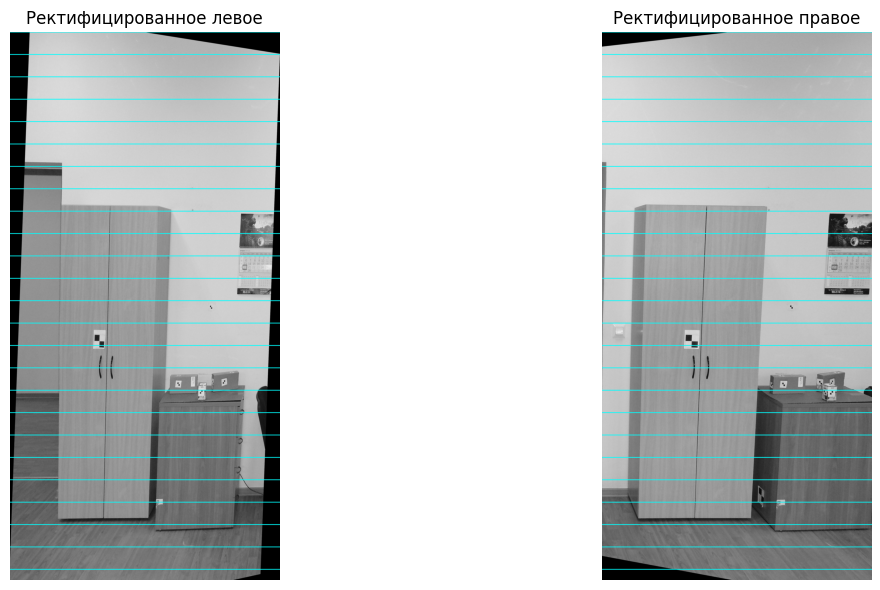

In [23]:
show_rectified(rect_crop)

# Построение карты диспаритета

In [24]:
stereo = cv2.StereoSGBM_create(
    minDisparity=0,
    numDisparities=64,
    blockSize=3,
    P1=8 * 1 * 3 ** 2,
    P2=32 * 1 * 3 ** 2,
    disp12MaxDiff=1,
    uniquenessRatio=5,
    speckleWindowSize=0,
    speckleRange=4,
    preFilterCap=31,
    mode=cv2.STEREO_SGBM_MODE_SGBM_3WAY
)

disparity = stereo.compute(rect_eq[0], rect_eq[1]).astype(np.float32) / 16.0

print("Статистика диспаритета:")
print(f"min: {np.min(disparity)}")
print(f"max: {np.max(disparity)}")
print(f"mean: {np.mean(disparity)}")
print(f"std: {np.std(disparity)}")

Статистика диспаритета:
min: -1.0
max: 63.0
mean: 15.344026565551758
std: 19.43225860595703


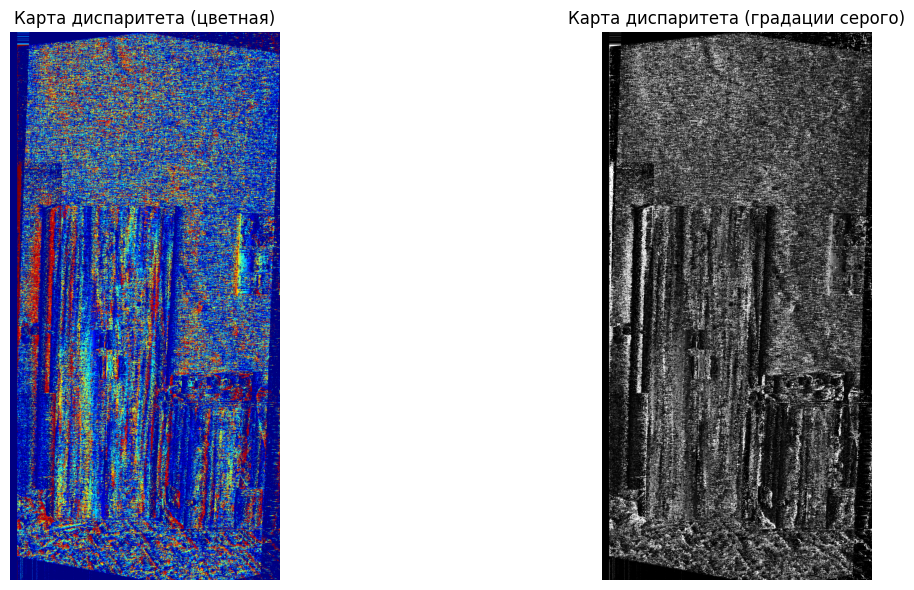

In [25]:
disp_vis = disparity.copy()
disp_vis[disp_vis < 0] = 0

disp_norm = cv2.normalize(disp_vis, None, 0, 255, cv2.NORM_MINMAX)
disp_norm = disp_norm.astype(np.uint8)

disp_color = cv2.applyColorMap(disp_norm, cv2.COLORMAP_JET)
disp_color = cv2.cvtColor(disp_color, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
plt.imshow(disp_color)
plt.title("Карта диспаритета (цветная)")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(disp_norm, cmap='gray')
plt.title("Карта диспаритета (градации серого)")
plt.axis('off')

plt.tight_layout()
plt.show()